In [2]:
import sys
from typing import Any, Dict
from pathlib import Path

import numpy as np

from SysSimX.core.base import CoSimComponent
from SysSimX.core.port import PortSpec, PortType
from SysSimX.core.events import EventLocator
from SysSimX.utilities.units import Quantity
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [3]:
class Pendulum(FMUComponent):
    """
    FMU-based pendulum component with rollback support.
    """
    def __init__(self, name, group = None):
        fmu_path = Path.cwd().parent / "FMUs" / "Pendulum_Cvode.fmu"
        super().__init__(name, fmu_path, group)

    def snapshot_state(self):
        """Create a snapshot of the current component state."""
        state = super().get_state()
        state["t"] = self.t
        return state

    def restore_state(self, snapshot, t):
        """Restore component to a previous state from snapshot."""
        self.t = t
        q0 = snapshot['q']['value']
        omega0 = snapshot['omega']['value']
        self._instance.reset()
        self._instance.instantiate()
        self._instance.setupExperiment(startTime=t)
        self._instance.enterInitializationMode()
        self.set_parameters(**{'q0': q0, 'omega0': omega0})
        self._apply_parameters_starts()
        self._apply_input_starts()
        self._instance.exitInitializationMode()

        self._update_output_states(t)
        self._record_outputs(t)

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        restitution = 1
        output = self.get_outputs()
        q0 = output['q'].magnitude
        omega0 = -restitution * output['omega'].magnitude

        self._instance.reset()
        self._instance.instantiate()
        self._instance.setupExperiment(startTime=t)
        self._instance.enterInitializationMode()
        self.set_parameters(**{'q0': q0, 'omega0': omega0})
        self._apply_parameters_starts()
        self._apply_input_starts()
        self._instance.exitInitializationMode()

        self._update_output_states(t)
        self._record_outputs(t)

In [4]:
fmu_path = "../test_data/FMUs/Pendulum_Cvode.fmu"
pendulum = Pendulum(name="Pendulum")
pendulum.set_parameters(q0=0.3)
pendulum.initialize(t0=0.0)

def event_indicator(comp: Pendulum) -> float:
    """Event indicator function for the pendulum component."""
    return comp.get_outputs()['q']

pendulum.add_event_indicator(name="wall_hit",
                             func=event_indicator,
                             direction=-1)

t = 0.0
dt_initial = 0.01
t_end = 1

locator = EventLocator(tol_value=1e-5, max_iter=50)

events = None
t_left = t
t_right = t + dt_initial

while t < t_end:
    # 1) Save state before the step
    snapshot_before = pendulum.snapshot_state()
    
    # 2) Evaluate event indicators
    g_before = pendulum.evaluate_event_indicators()
    
    # 3) Perform the step
    if events:
        dt = t_right - t
    else:
        dt = dt_initial
    pendulum.do_step(t, dt)
    
    # 4) Evaluate event indicators after the step
    g_after = pendulum.evaluate_event_indicators()
    
    # 5) Check for events
    events = pendulum.detect_event_crossing(g_before, g_after)
    
    if events:
        t_left = t
        t_right = t + dt
        dt_initial = dt

        print(f"\n{'='*60}")
        print(f"Event detected in interval [{t_left:.4f}, {t_right:.4f}]")
        print(f"Events: {events}")
        print(f"{'='*60}\n")

        components = {pendulum.name: pendulum}
        snapshots = {pendulum.name: snapshot_before}

        t_event, detected_events, success = locator.locate_event(components,
                                                                 snapshots,
                                                                 t_left,
                                                                 t_right,
                                                                 verbose=True)

        if success:
            print(f"\n{'='*60}")
            print(f"Event located at t={t_event:.8f}")
            print(f"Events: {detected_events}")
            print(f"{'='*60}\n")
            
            # 7) Handle the event
            event_names = [event_name for comp_name, event_name in detected_events]
            pendulum.handle_event(event_names, t_event)
            
            # Update time and continue
            t = t_event
        else:
            print("Warning: Event location failed, continuing...")
            t += dt
    else:
        t += dt

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF

Event detected in interval [0.4300, 0.4400]
Events: ['wall_hit']

Itera

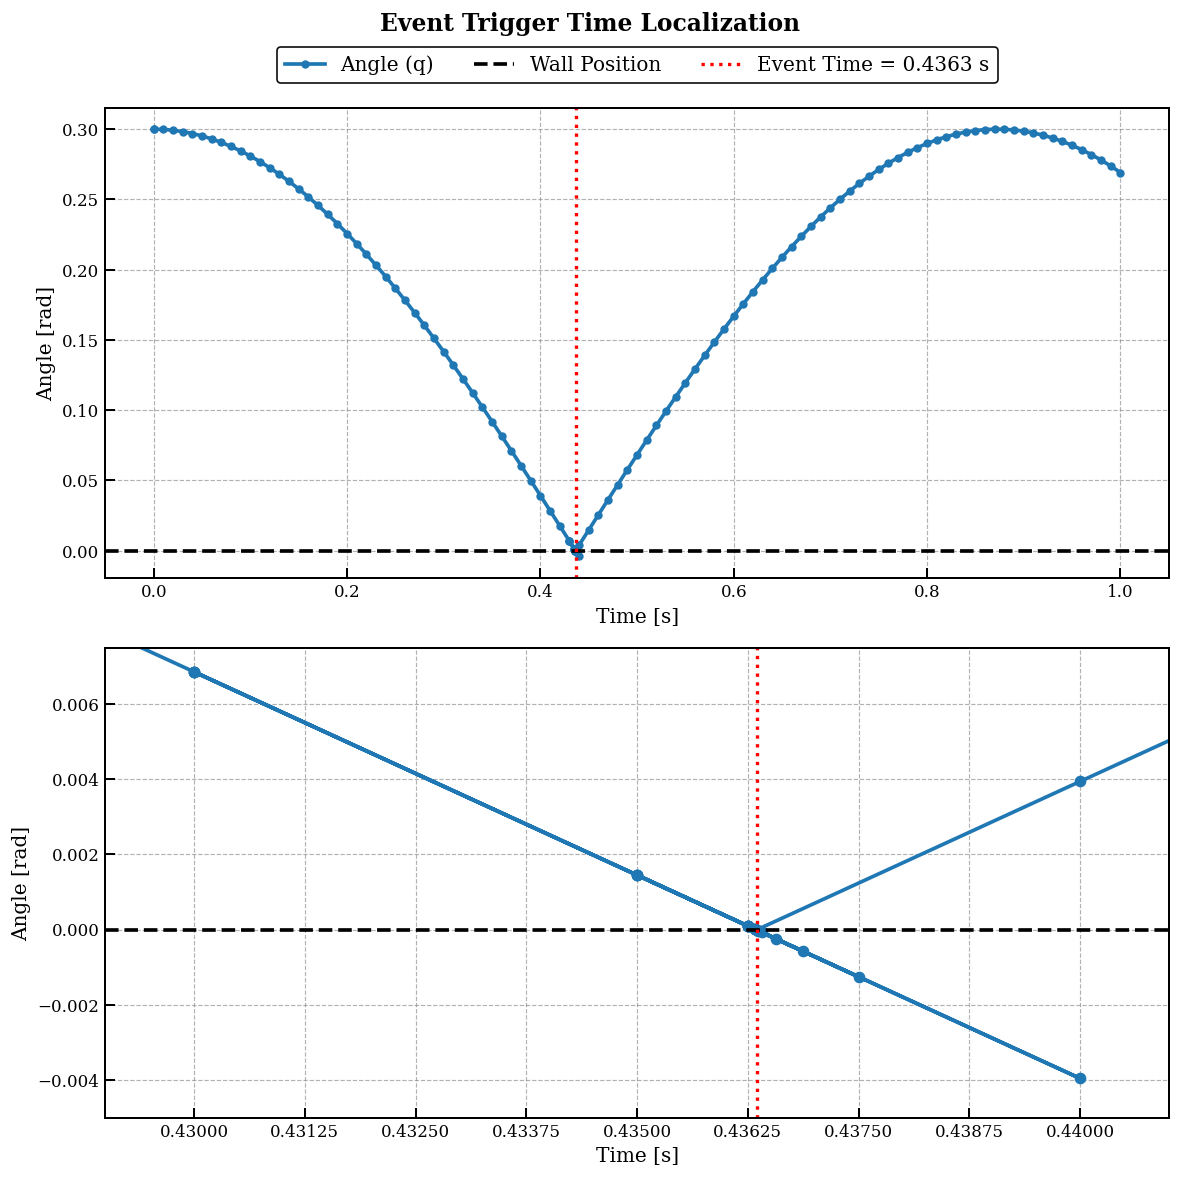

In [ ]:
time_values, port_histories = pendulum.get_history_arrays()

q_vals = port_histories['q']
omega_vals = port_histories['omega']

plt.figure(figsize=(10, 10))
plt.suptitle('Event Trigger Time Localization', fontweight='bold', fontsize=14)
plt.subplot(2, 1, 1)
plt.plot(time_values, q_vals, label='Pendulum Angle', marker='o', markersize=4)
plt.axhline(0, color='k', linestyle='--', label='Wall Position')
plt.axvline(t_event, color='red', linestyle=':', linewidth=2, label=f'Event Time = {t_event:.4f} s')
plt.xlabel('Time [s]')
plt.ylabel('Angle [rad]')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time_values, q_vals, label='Angle (q)', marker='o', markersize=6)
plt.axhline(0, color='k', linestyle='--', label='Wall Position')
plt.axvline(t_event, color='red', linestyle=':', linewidth=2)
plt.xticks(np.arange(0.4275, 0.44225, 0.00125))
plt.xlim(0.429, 0.441)
plt.ylim(-0.005, 0.0075)
plt.xlabel('Time [s]')
plt.ylabel('Angle [rad]')
plt.grid()
plt.tight_layout()
plt.savefig('../figures/Hybrid/test_2_location.svg')



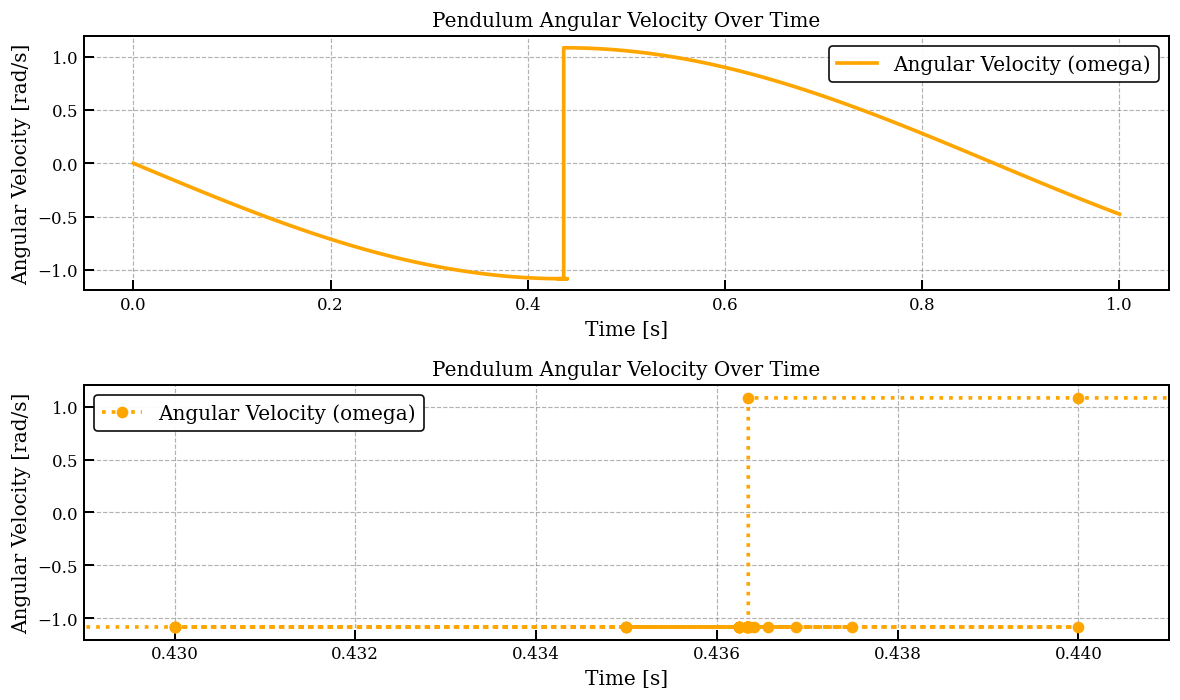

In [6]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(time_values, omega_vals, label='Angular Velocity (omega)', color='orange')
plt.title('Pendulum Angular Velocity Over Time')
plt.xlabel('Time [s]')
plt.ylabel('Angular Velocity [rad/s]')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time_values, omega_vals, label='Angular Velocity (omega)', color='orange', marker='o', markersize=6, linestyle=':')
plt.title('Pendulum Angular Velocity Over Time')
plt.xlim(0.429, 0.441)
plt.ylim(-1.2, 1.2)
plt.xlabel('Time [s]')
plt.ylabel('Angular Velocity [rad/s]')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()